In [1]:
#please porvide path to psrpoppy
# seperates the smeared pulsars
%reset -f
import sys
sys.path.append('path to psrpoppy')
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit



sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'

with open(filename, 'rb') as f:
    pop = pickle.load(f)


fluxes = np.array([psr.s_1400() for psr in pop.population])*10**-26  
distances = np.array([psr.dtrue for psr in pop.population])*1e3
luminosities = np.array([psr.lum_1400 for psr in pop.population])
snr = np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)


df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'luminosity':luminosities,
    'snr':snr
})

df_smr = df[df['snr']==-1]

# Save the filtered DataFrame to Excel
df_smr.to_excel("df_smr.xlsx", index=False)
print(len(df_smr))

number of pulsars 229744
56514


number of pulsars 229744
                Flux      Distance         snr
2       4.109254e-29   7418.271416    0.340220
4       4.093381e-29   6770.115336    0.249322
6       6.988890e-31  14837.611782    0.001193
7       1.684376e-30  10334.407362    0.006663
8       1.228404e-30  13491.873125    0.006149
...              ...           ...         ...
229738  6.590731e-30   6900.124556    0.047750
229740  7.873527e-29   8666.075125    0.444286
229741  2.174073e-29  14180.978801    0.162316
229742  3.899249e-30   7657.284657    0.029673
229743  2.338865e-26   4417.275743  214.654795

[130781 rows x 3 columns]
log_flux_cut 2.8865385272198237e-30 -29.539622641509432


<IPython.core.display.Javascript object>


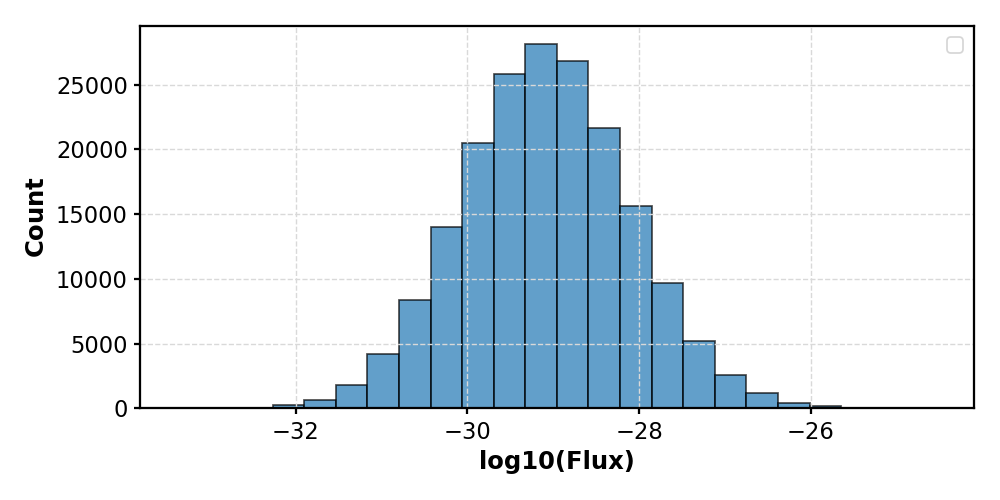

/tmp/ipykernel_3523/3724183777.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


                Flux      Distance       snr  luminosity
0       4.109254e-29   7418.271416  0.340220         NaN
1       4.093381e-29   6770.115336  0.249322         NaN
8       1.651596e-29   8421.284184  0.076698         NaN
9       3.050391e-28  12899.471170  0.213547         NaN
11      1.978285e-28   5335.487893  1.663684         NaN
...              ...           ...       ...         ...
187287  7.841389e-30  13257.735450 -1.000000    0.137826
187289  5.681587e-30  18105.646945 -1.000000    0.186251
187290  5.353707e-30  16567.071912 -1.000000    0.146942
187293  6.932446e-30  11287.983880 -1.000000    0.088332
187294  1.336024e-28  12272.135977 -1.000000    2.012123

[127171 rows x 4 columns]


<IPython.core.display.Javascript object>


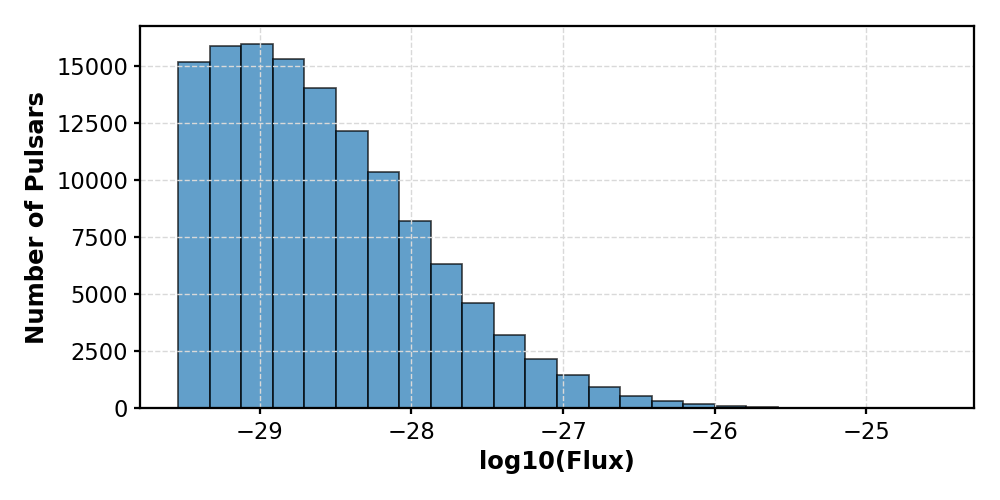

<IPython.core.display.Javascript object>


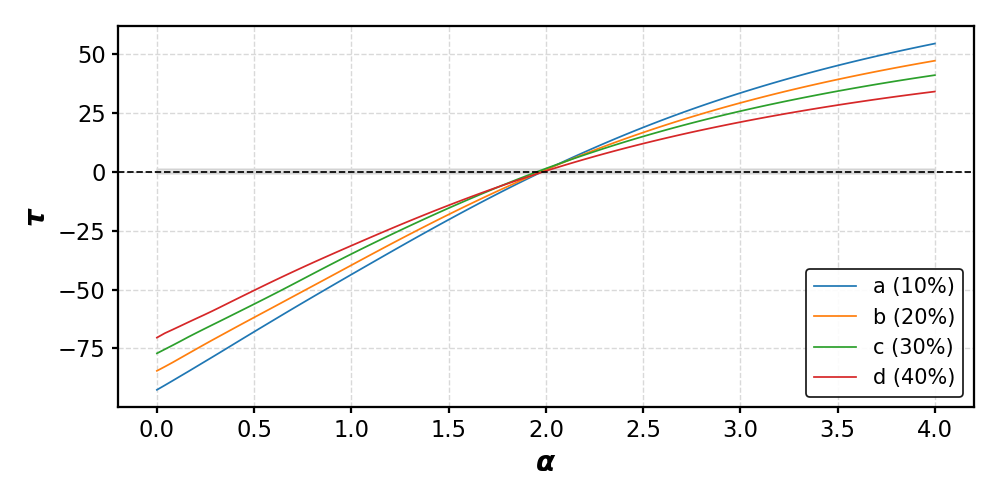


Computing for quantile=a (10%), flux threshold=0.00
Done in 155.0s

Computing for quantile=b (20%), flux threshold=0.00
Done in 118.5s

Computing for quantile=c (30%), flux threshold=0.00
Done in 88.8s

Computing for quantile=d (40%), flux threshold=0.00
Done in 65.6s


In [7]:
#currently code is set for snr=0 cut and snr equivalent flux cut according to regression relation shown in fig 5 as snr=0.01  
#comment out the concatenating step of df_smr to avoid smeared = fig7 of paper
#code currently set to reproduce FIG 8a

%reset -f
%matplotlib notebook
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import matplotlib as mpl
import sys
sys.path.append('path to prsrpoppy')
mpl.rcParams.update({
    "font.size": 14,                
    "axes.labelweight": "bold",     
    "axes.titlesize": 16,           
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,          
    "lines.linewidth": 1,         
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "font.weight": "normal",
})
sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'

df_smr = pd.read_excel("df_smr.xlsx")                           ################ change file or comemnt out if smeared not required
#print(df_smr)

with open(filename, 'rb') as f:
    pop = pickle.load(f)

# Extract data
fluxes = np.array([psr.s_1400() for psr in pop.population])*10**-26  
distances = np.array([psr.dtrue for psr in pop.population])*1e3
luminosities = np.array([psr.lum_1400 for psr in pop.population])
snr = np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)

# Build DataFrame (read-only)
df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})
df=df[df["snr"] >=0]  #selecting only positive snr's change this to introduce snr cut
print(df)

#df = pd.concat([df, df_smr], ignore_index=True)                #adding smeared pulsars  to the dataset comment it to avoid this 
log_snr=np.log10(0.01)  #to get flux equivalent of snr according to linear regression line in fig 5
flux_cut=10**((log_snr-29.312)/1.060)           

print("log_flux_cut",flux_cut,np.log10(flux_cut))


# ---- Histogram before cut (log scale y) ----
plt.figure(figsize=(8,4))
plt.hist(np.log10(df['Flux'].dropna()), bins=24, alpha=0.7,edgecolor='black', linewidth=1.0)
#plt.axvline(-3.61, color='r', linestyle='--')
#plt.axvline(-2.76, color='r', linestyle='--')
plt.xlabel("log10(Flux)")
plt.ylabel(r"$\mathbf{Count}$")

#plt.title("Histogram of Pulsar Fluxes (Before Cut)")
plt.legend()
plt.tight_layout()
plt.show()




df=df[df['Flux']>=flux_cut]                #flux cut
print(df)

# ---- Histogram after cut (log scale y) ----
plt.figure(figsize=(8,4))
plt.hist(np.log10(df['Flux'].dropna()), bins=24, alpha=0.7,edgecolor='black', linewidth=1.0)
#plt.axvline(-3.50, color='r', linestyle='--')
#plt.axvline(-2., color='r', linestyle='--')
plt.xlabel("log10(Flux)")
plt.ylabel("Number of Pulsars")
#plt.title("Histogram of Pulsar Fluxes (After Cut)")
plt.tight_layout()
plt.show()



df['Flux_log'] = np.log10(df['Flux'])
df['Dist_log'] = np.log10(df['Distance'])

def compute_LogLth(D_array, flux_thresh, alpha):
    """Compute log10(flux_thresh * D^alpha)"""
    return np.log10(flux_thresh) + alpha * np.log10(D_array)
plt.figure(figsize=(8,4))
@njit
def compute_tau_numba(D_logs, Lprime_logs, thresh, alpha):
    n = len(D_logs)
    N_a = np.zeros(n, dtype=np.int64)
    R_a = np.zeros(n, dtype=np.int64)
    E_a = np.zeros(n)
    V_a = np.zeros(n)
    
    for i in range(n):
        Di = D_logs[i]
        Li = Lprime_logs[i]
        L_thi = np.log10(thresh * (10 ** Di) ** alpha)
        N_count = 0
        R_count = 0
        for j in range(n):
            D = D_logs[j]
            L = Lprime_logs[j]
            if (D <= Di) and (L >= L_thi):
                N_count += 1
                if Li >= L:
                    R_count += 1
        N_a[i] = N_count
        R_a[i] = R_count
        E_a[i] = 0.5 * (N_count + 1)
        V_a[i] = (N_count ** 2 - 1) / 12 if N_count > 0 else 0.0

    numerator = np.sum(R_a - E_a)
    denominator = np.sqrt(np.sum(V_a))
    return numerator / denominator if denominator != 0 else np.nan

def compute_tau_for_alpha(alpha_thresh):
    alpha, thresh = alpha_thresh

   
    LogLthA = compute_LogLth(df['Distance'].values, thresh, alpha)

    
    Lprime_Log = df['Flux_log'].values + alpha * df['Dist_log'].values

    
    mask = Lprime_Log >= LogLthA
    D_logs = df['Dist_log'].values[mask]
    Lprime_logs = Lprime_Log[mask]

    if len(D_logs) == 0:
        return alpha, np.nan

    tau = compute_tau_numba(D_logs, Lprime_logs, thresh, alpha)
    return alpha, tau

if __name__ == '__main__':
    #plt.figure(figsize=(8,6))
    quantiles = ['a (10%)', 'b (20%)', 'c (30%)', 'd (40%)']
    quantiles_num =[10,20,30,40]                                                               #no flux threshold removal 
    flux_thresholds = np.percentile(df["Flux"],quantiles_num)
    alphas = np.linspace(0,4,100)

    for q, thresh in zip(quantiles, flux_thresholds):
        print(f"\nComputing for quantile={q}, flux threshold={thresh:.2f}")
        start = time.time()

        alpha_thresh_list = [(alpha, thresh) for alpha in alphas]

        
        with multiprocessing.Pool(processes=4) as pool:
            results = pool.map(compute_tau_for_alpha, alpha_thresh_list)

      
        results.sort()
        taus = [tau for alpha, tau in results]

        print(f"Done in {time.time() - start:.1f}s")
        plt.plot(alphas, taus, label=f"{q}")

    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel(r'$\boldsymbol{\alpha}$', fontsize=16) 
    plt.ylabel(r'$\boldsymbol{\tau}$', fontsize=16)


    #plt.title(f'Efron–Petrosian $\\tau$ vs $\\alpha$ rdist=lfl06 psrpoppy {filename[13:-8]}')
   # plt.figtext(0.5, 0.01, f"snr=0.0 dataset with smeared population ,flux cut={flux_cut} corr. to snr=0.01" ,ha="center", fontsize=9, color="gray")
    plt.fill_between(alphas, -1, 1, color='gray', alpha=0.2)
    plt.legend(frameon=True, loc="lower right", facecolor='white', framealpha=0.9, edgecolor='black')
   # plt.savefig("/mnt/e/pulsar/plots/efron_petrosian_tau_alpha_smeared_snr_0_lfl06_fluxcuteq_0.01.pdf", dpi=1000, bbox_inches="tight")
    plt.grid(True,zorder=1)
    plt.tight_layout()
    plt.show()

